# 01 · P300 speller: from flashes to ERPs

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Load a real P300 speller recording, inspect target imbalance, visualize event-related activity and extract temporal features.

**Data:** BNCI2014-009, subject 1, three sessions; MOABB → MNE

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

A row/column speller briefly intensifies groups of symbols. The attended group is a target; other groups are non-targets. A target can evoke a positive deflection several hundred milliseconds later, but latency and amplitude vary and a P300 is not guaranteed on each flash. Attention, fatigue and overlapping responses matter.

An epoch is $X_i(c,\tau)=x_c(t_i+\tau)$. An ERP is $\bar X_k(c,\tau)=N_k^{-1}\sum_{i:y_i=k}X_i(c,\tau)$. Averaging reduces independent zero-mean noise approximately as $1/\sqrt{N_k}$; this does not remove systematic artifacts. A time-window feature is $z_{icw}=|W|^{-1}\sum_{\tau\in W}X_i(c,\tau)$.

We use BNCI2014-009 through MOABB. It is a **P300 speller dataset, not BCI Competition II/III speller data**. MOABB returns MNE epochs and preserves session/run metadata, but its binary paradigm interface does not provide enough character/flash identity for verified text decoding. Notebook 02 separates real target detection from a controlled character-decoding exercise.

We choose a 0.5–20 Hz passband and 0–0.8 s epochs. No pre-stimulus baseline is available in this extraction; do not claim one was applied. Nearby flash epochs overlap: randomly splitting individual flashes risks shared signal and character context across train and test. Hold out entire sessions.

## Load real speller epochs
The loader filters and resamples; it returns EEG in volts. Check class labels rather than assuming numeric codes.

In [2]:
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300
dataset = BNCI2014_009()
paradigm = P300(fmin=0.5, fmax=20, tmin=0, tmax=0.8, resample=128)
epochs, labels, metadata_p300 = paradigm.get_data(
    dataset=dataset, subjects=[1], return_epochs=True)
y = (np.asarray(labels) == 'Target').astype(int)
X = epochs.get_data(copy=True)  # volts; epochs x channels x samples
session = metadata_p300['session'].astype(str).to_numpy()
assert X.shape[0] == len(y) == len(session)
assert set(np.unique(y)) == {0, 1}
print(pd.crosstab(session, np.asarray(labels)))
print('Shape:', X.shape, 'sampling:', epochs.info['sfreq'], 'Hz')

This is nemar-py 0.3.0.
Preparing to download nm000188 from https://data.nemar.org/


Retrieving 5 of 351 manifest files (16 concurrent downloads).
primary backend failed; falling back to next layer: 'README.md' is not annexed (no sha256/md5 checksum on the manifest entry); the S3 backend has nothing to fetch.


Overall:   0%|          | 0.00/12.1k [00:00<?, ?B/s]

Finished downloading nm000188 v1.0.2.
This is nemar-py 0.3.0.
Preparing to download nm000188 from https://data.nemar.org/


Retrieving 5 of 351 manifest files (16 concurrent downloads).


S3:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Finished downloading nm000188 v1.0.2.


/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/home/berdakh/Documents/Codex/2026-09-23/in-berdakh-bci-gan-update-the/work/venv/lib/python3.13/site-packages/moabb/datasets/bnci/base.py:494: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")


col_0  NonTarget  Target
row_0                   
0            480      96
1            480      96
2            480      96
Shape: (1728, 16, 103) sampling: 128.0 Hz


## Inspect the ERP
Plot the nearest available parietal channel. These averages are descriptive; do not choose a classification time window using the held-out session.

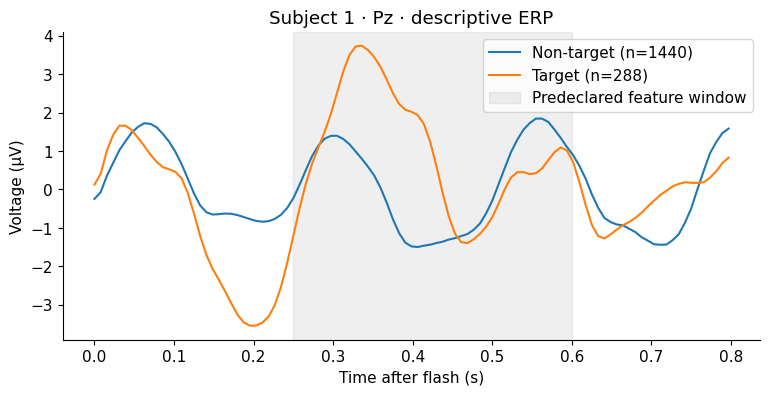

In [3]:
channel = 'Pz' if 'Pz' in epochs.ch_names else epochs.ch_names[-1]
c = epochs.ch_names.index(channel)
fig, ax = plt.subplots()
for label, name in [(0,'Non-target'),(1,'Target')]:
    ax.plot(epochs.times, X[y==label,c].mean(0)*1e6, label=f'{name} (n={(y==label).sum()})')
ax.axvspan(.25,.6,color='gray',alpha=.12,label='Predeclared feature window')
ax.set(xlabel='Time after flash (s)',ylabel='Voltage (µV)',title=f'Subject 1 · {channel} · descriptive ERP')
ax.legend(); plt.show()

## Extract interpretable features
Use several predeclared windows so a classifier can combine channels and latencies.

In [4]:
windows = [(0.1,0.25),(0.25,0.4),(0.4,0.6),(0.6,0.8)]
features = np.concatenate([X[:,:, (epochs.times>=a)&(epochs.times<b)].mean(-1)
                           for a,b in windows], axis=1)
assert features.shape == (len(y), len(epochs.ch_names)*len(windows))
print('Features:', features.shape, 'target fraction:', y.mean())
print('Always non-target accuracy:', (y==0).mean(), 'balanced accuracy: 0.5')

Features: (1728, 64) target fraction: 0.16666666666666666
Always non-target accuracy: 0.8333333333333334 balanced accuracy: 0.5


## Exercises and checks
1. Compare target and non-target trial counts. Why is raw accuracy misleading?
2. Plot a single epoch beside its class average and explain the difference.
3. Use only training sessions to compare Pz and Cz. Predeclare your selected channels before evaluating session 3.
4. Explain why high-pass filtering at 8 Hz would damage this task.

## Next steps and sources
[Dataset documentation](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_009.html) · [MNE epochs](https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.